In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [1]:
import os

for root, dirs, files in os.walk('/kaggle/input'):
    for file in files:
        print(os.path.join(root, file))

/kaggle/input/datasets/carrie1/ecommerce-data/data.csv


In [6]:
import os
import pandas as pd
import numpy as np
path = '/kaggle/input/datasets/carrie1/ecommerce-data/data.csv'
df = pd.read_csv(path, encoding='latin1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [7]:
print(f"Total Rows: {df.shape[0]}, Total Columns: {df.shape[1]}")
print("\nMissing values per column:")
print(df.isnull().sum())

Total Rows: 541909, Total Columns: 8

Missing values per column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [8]:
df_clean = df.dropna(subset=['CustomerID']).copy()
df_clean['CustomerID']= df_clean['CustomerID'].astype(int)
print("Remaining rows after dropping missing CustomerID:", df_clean.shape[0])

Remaining rows after dropping missing CustomerID: 406829


In [9]:
print("Negative Quantity rows:", (df_clean['Quantity']<=0).sum())
print("Zero or negative UnitPrice rows:",(df_clean['UnitPrice'] <=0).sum())
df_clean = df_clean[(df_clean['Quantity']>0) & (df_clean['UnitPrice']>0)]

Negative Quantity rows: 8905
Zero or negative UnitPrice rows: 40


In [10]:
duplicates = df_clean.duplicated().sum()
print("Duplicate rows found:", duplicates)
# remove duplicates
df_clean = df_clean.drop_duplicates()
print("Shape after removing duplicates:", df_clean.shape)

Duplicate rows found: 5192
Shape after removing duplicates: (392692, 8)


In [11]:
# convert invoice date into datetime format
df_clean['InvoiceDate']= pd.to_datetime(df_clean['InvoiceDate'])
# Create total spend column (Quantity * UnitPrice)
df_clean['TotalSpend'] = df_clean['Quantity'] * df_clean['UnitPrice']
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalSpend
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [12]:
# Save clean file into Kaggle output
df_clean.to_csv('ecommerce_cleaned_data.csv', index=False)
print("Data cleaning complete and saved successfully!")

Data cleaning complete and saved successfully!


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Visual style setup
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10,5)

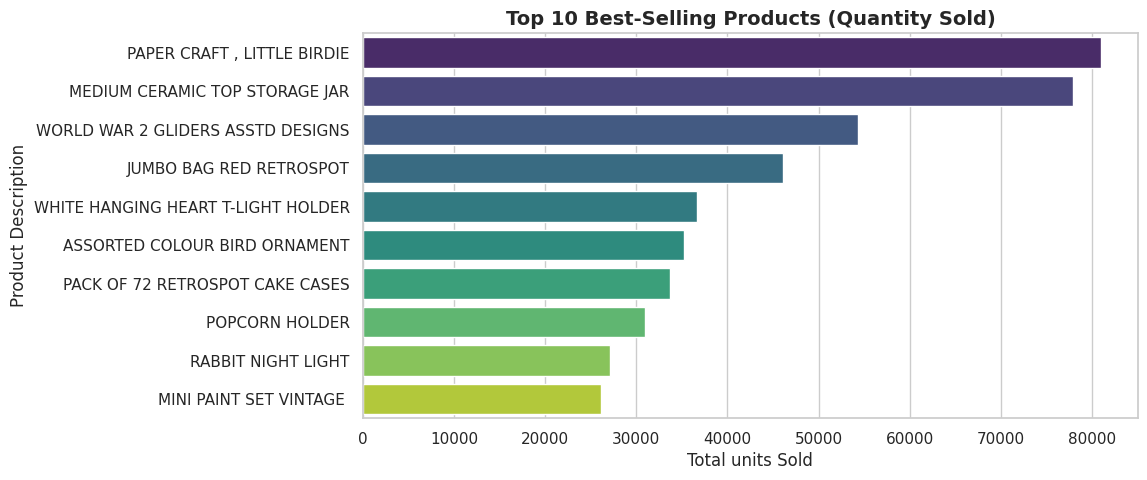

In [15]:
top_products = (
    df_clean.groupby('Description')['Quantity']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_products, x='Quantity', y='Description',hue='Description', palette='viridis', legend=False)
plt.title('Top 10 Best-Selling Products (Quantity Sold)', fontsize=14, weight='bold')
plt.xlabel('Total units Sold')
plt.ylabel('Product Description')
plt.show()

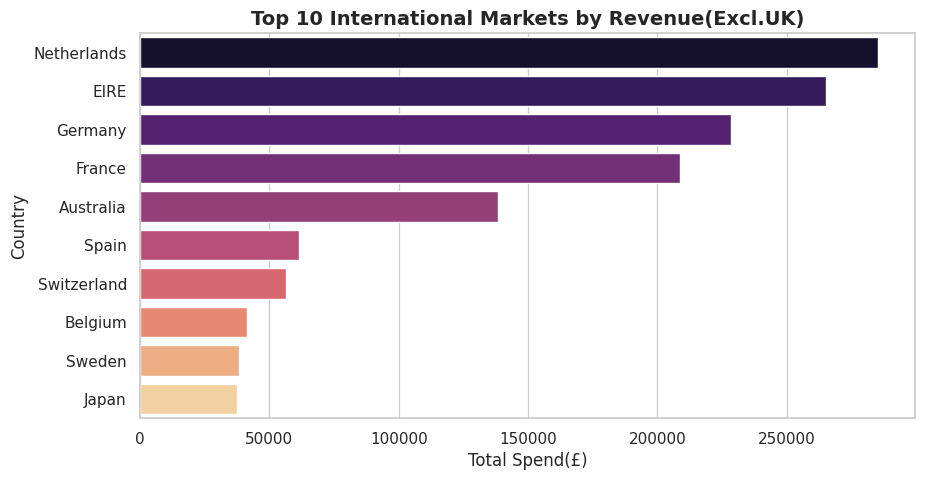

In [20]:
top_countries = (
    df_clean[df_clean['Country'] != 'United Kingdom']
    .groupby('Country')['TotalSpend']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(10,5))
sns.barplot(data=top_countries, x='TotalSpend', y='Country',hue='Country', palette='magma',legend=False)
plt.title('Top 10 International Markets by Revenue(Excl.UK)',fontsize=14,weight='bold')
plt.xlabel('Total Spend(£)')
plt.ylabel('Country')
plt.show()

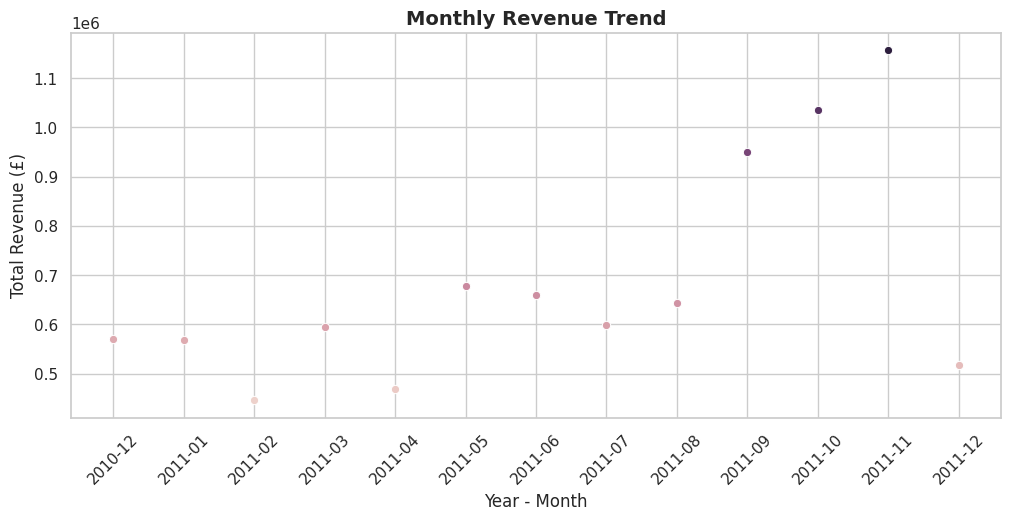

In [24]:
# Year-Month feature
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
monthly_revenue = df_clean.groupby('YearMonth')['TotalSpend'].sum().reset_index()
monthly_revenue['YearMonth'] = monthly_revenue['YearMonth'].astype(str)
plt.figure(figsize = (12,5))
sns.lineplot(data=monthly_revenue, x = 'YearMonth', y='TotalSpend',hue = 'TotalSpend', marker='o', color='royalblue', linewidth=2.5, legend=False)
plt.title('Monthly Revenue Trend', fontsize=14,weight='bold')
plt.xlabel('Year - Month')
plt.ylabel('Total Revenue (£)')
plt.xticks(rotation=45)
plt.show()

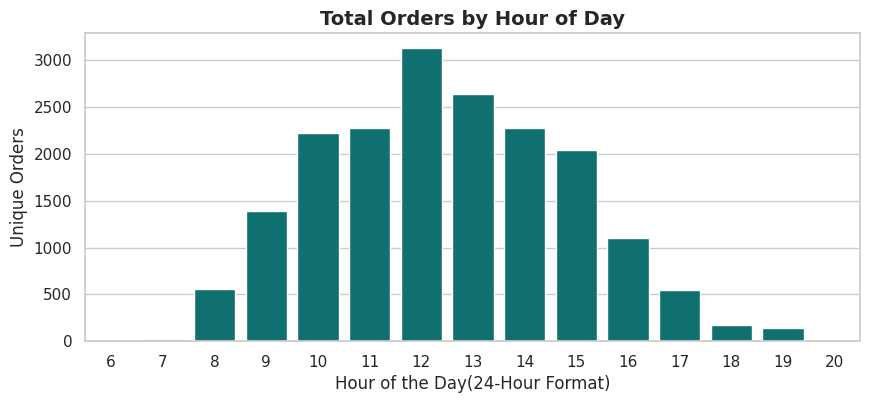

In [27]:
df_clean['Hour'] = df_clean['InvoiceDate'].dt.hour
hourly_orders = df_clean.groupby('Hour')['InvoiceNo'].nunique().reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=hourly_orders, x='Hour', y='InvoiceNo', color='teal')
plt.title('Total Orders by Hour of Day', fontsize=14, weight='bold')
plt.xlabel('Hour of the Day(24-Hour Format)')
plt.ylabel('Unique Orders')
plt.show()